**Aggregation Model**

In [2]:
## DATA AND PACKAGE IMPORT 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace    


# formatting for plots
font = {'family': 'DejaVu Serif',
        'color': 'k',
        'weight': 'normal',
        'size': 12}
legend_font = font.copy()
legend_font['size'] = font['size'] - 1
legend_font.pop('color', None)

'k'

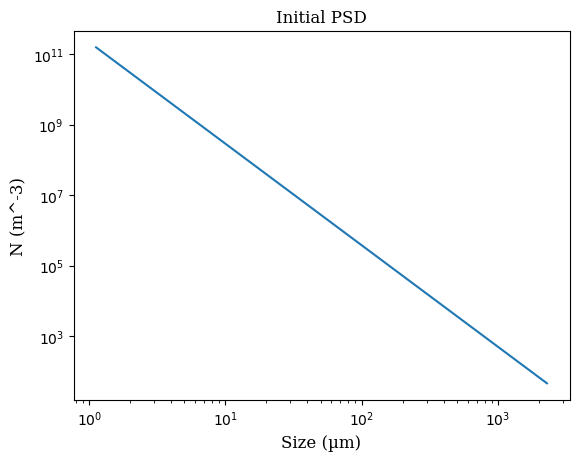

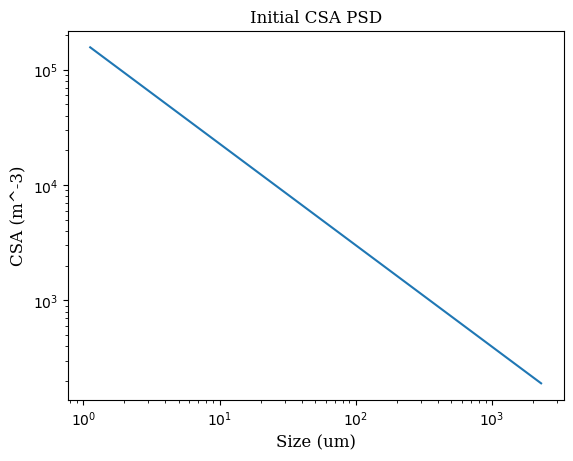

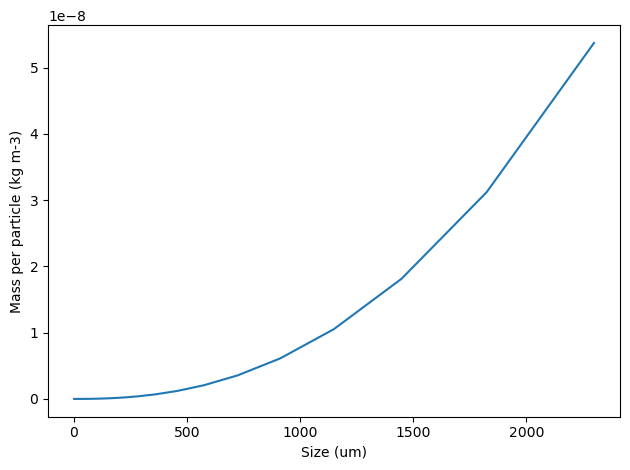

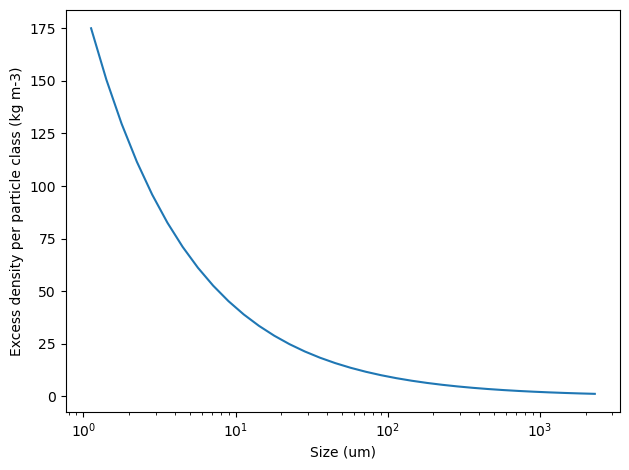

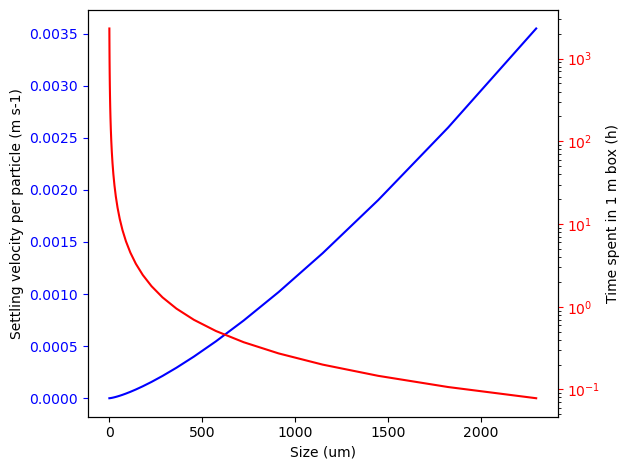

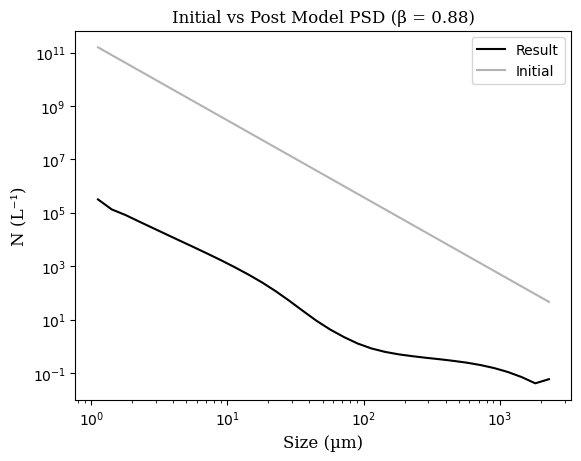

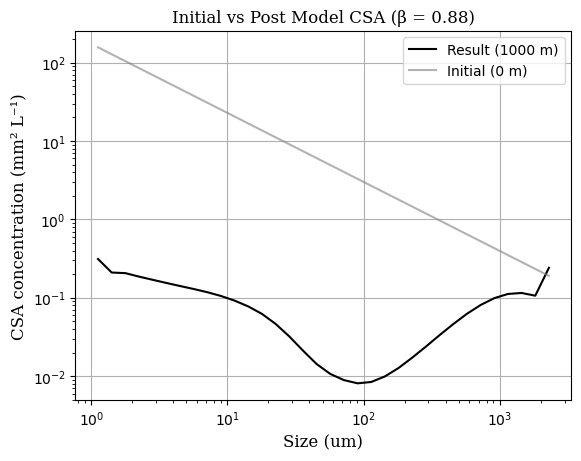

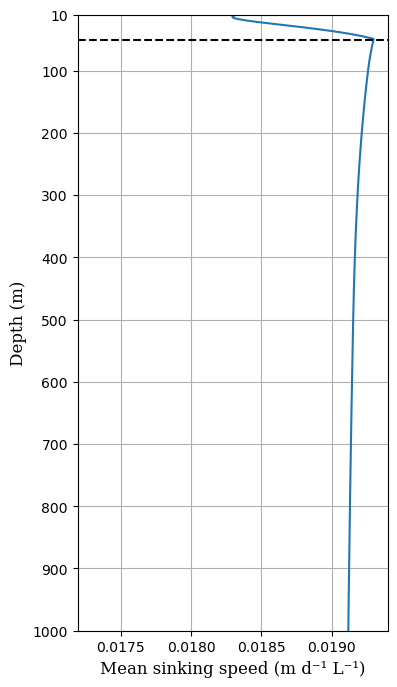

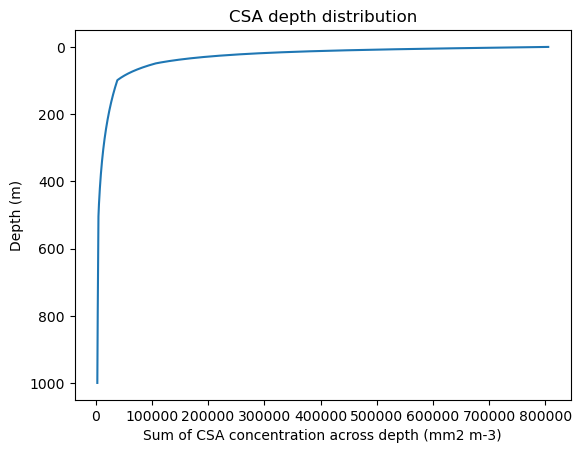

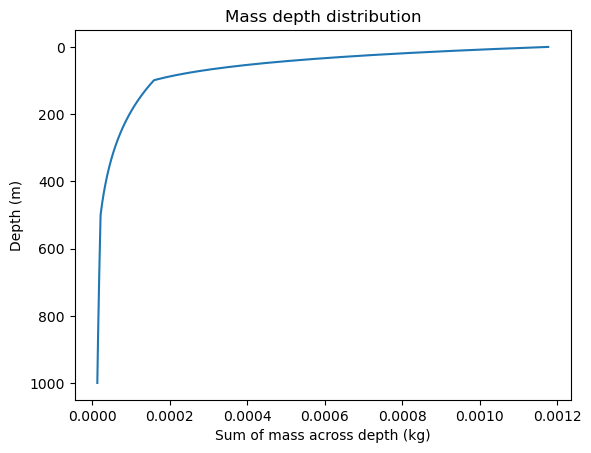

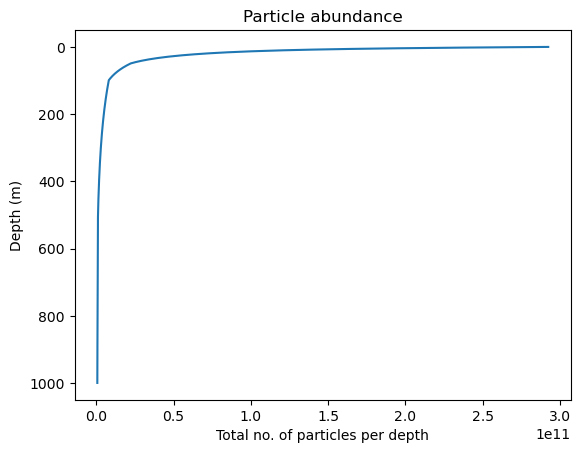

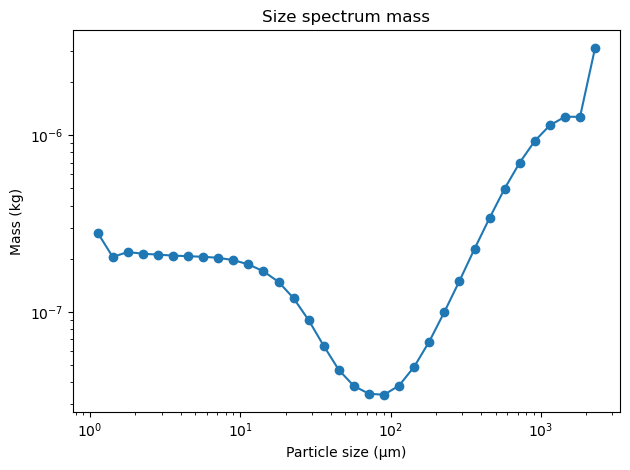

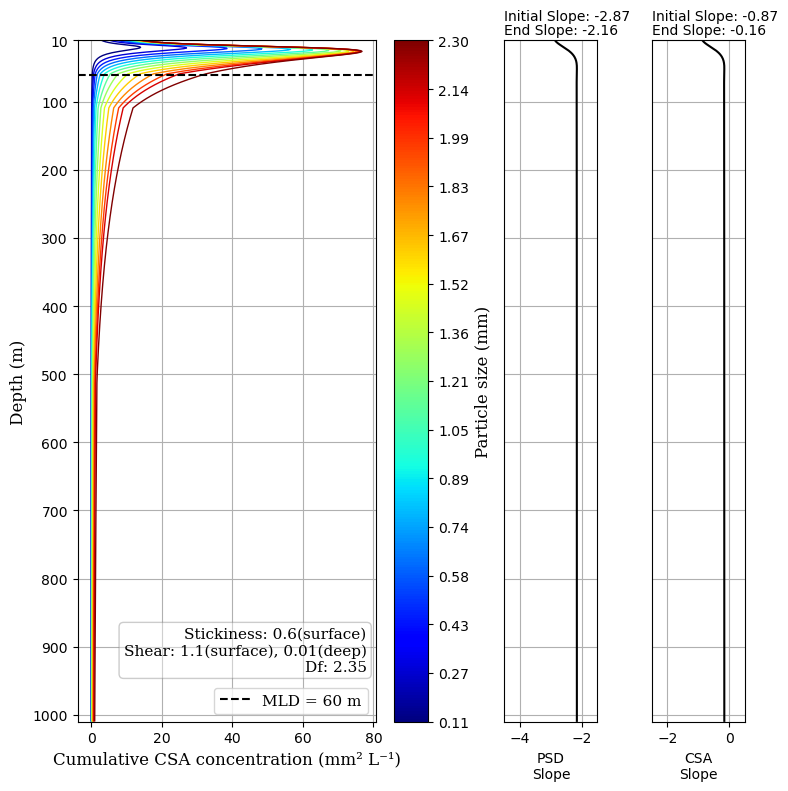

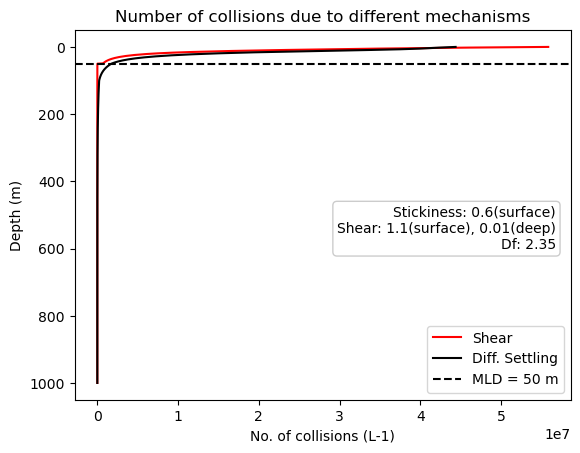

'\n# Writing respective runs to files\n\nM_profile = pd.DataFrame(M_profile)\nCSA_profile = pd.DataFrame(CSA_profile)\nPSD_slope_results = pd.DataFrame(PSD_results)\nCSA_slope_results = pd.DataFrame(CSA_results)\n#mg_POC = pd.DataFrame(mg_POC)\ninitial_CSA = pd.DataFrame(initial_CSA)\nCSA = pd.DataFrame(CSA)\nturb_agg = pd.DataFrame(shear_collision_profile)\ndiff_agg = pd.DataFrame(settling_collision_profile)\nsink_velocities = pd.DataFrame(sink_velocities)\nmean_sink_velocities = pd.DataFrame(mean_sink_velocities)\n\nmean_diameter_profile = pd.DataFrame(csa_weighted_mean_profile)\n\nwith pd.ExcelWriter(f"Model_Output_{four}.xlsx") as writer:                       # change the number in curly brackets according to the run you want to export\n    M_profile.to_excel(writer, sheet_name=\'Mass\', index=False)\n    CSA_profile.to_excel(writer, sheet_name=\'CSA\', index=False)\n    PSD_slope_results.to_excel(writer, sheet_name="PSD Slope", index=False)\n    CSA_slope_results.to_excel(writer,

In [ ]:
# MODEL


# SETTING UP SIZE CLASSES
#-------------------------------------

size_bounds = 2 ** np.arange(0, 11 + 1/3, 1/3) #um                  # 1 um to 25000 um (0, 13 bins)
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:]) # um        # calculates mid-size diameter of each bin as geometric mean (due to log spacing)
n_bins = len(size_bins)                                             # specifying the number of size bins

radius = size_bins / 2.0 #um                                       # calculates radius from diameter (um)
radius_m = radius / 1e6  #m                                        # converts radius into metres
radius_mm = radius / 1000  #mm                                     # converts radius into mm

area_per_particle = np.pi * radius_mm**2  # mm2                    # (mm2) calculates cross-sectional area (assuming each particle is a circle) for each size bin



# PARAMETERS
#-------------------------------------

Df = 2.35                                                           # Fractal Dimension
rho_f = 1025                         # kg m-3                       # Seawater Density (kg m-3)
rho0 = 1200                          # kg m-3  #(Li et al, 2004)    # Primary Particle Density (kg m-3)
mu = 1e-3                            # Pa s                         # Viscosity of seawater
g = 9.81                             # m s-2                        # Acceleration due to gravity
surface_a = 0.6                                                     # Stickiness (probability of successful collisions) at the surface
deep_a = 0.01                                                       # Stickiness (probability of successful collisions) at depth
surface_G = 1.1                      #s-1                           # Turbulent Shear at the surface
deep_G = 0.01                        #s-1                           # Turbulent Shear at depth
MLD = 50 #(will be 60 in profile due to 10 m offset)  # m           # Mixed Layer Depth



# INITIAL CSA DISTRIBUTION
#-------------------------------------

CSA0 = 850000 #(mm2 m-3)                                            # total surface starting particle cross-sectional area concentration
CSA_slope = 0.88                                                    # higher = steep, more small particles, lower = gentler, more large particles       

CSA = (size_bins / size_bins[0])**(-CSA_slope)                      # how much bigger is each size class than the smallest, then take the reciprocal to flip the probability so that biggest = rarest 
CSA = CSA / np.sum(CSA) * CSA0                                      # divide these individual weightings by their sum which is multiplied by the starting max CSA, so scaling their probabilities up

# number concentration 
N = CSA / area_per_particle  #(mm2 m-3 / mm2 = particles m-3)       # inferring the number of particles in each size class from the total cross-sectional area for each size class

# Mass
r0 = radius_m[0]    #reference particle (m)
V0 = (4/3) * np.pi * r0**3      #[] x [] x m3 = m3
m0 = rho0 * V0  #kg m-3 x m3 = kg
particle_mass = m0 * (radius_m / r0)**Df      #kg * (m/m)^2 which is [] = kg per particle (mass propor. to r^x)
M = N * particle_mass    # particles m-3 * kg = kg m-3 

# Roughly plotting PSD slope and CSA slope to check model behaviour

initial_N = N.copy()
fig, ax = plt.subplots()
ax.loglog(size_bins, initial_N)
ax.set_title("Initial PSD", fontdict=font)
ax.set_xlabel("Size (µm)", fontdict=font)
ax.set_ylabel("N (m^-3)", fontdict=font)

initial_CSA = CSA.copy()
fig, ax = plt.subplots()
ax.loglog(size_bins, initial_CSA)
ax.set_title("Initial CSA PSD", fontdict=font)
ax.set_xlabel("Size (um)", fontdict=font)
ax.set_ylabel("CSA (m^-3)", fontdict=font)




# FUNCTIONS: PARTICLE DENSITY, SETTLING VELOCITY, SHEAR + AGGREGATION
#-------------------------------------

def particle_density(r):
    """
    Calculates the excess density of a particle of given radius (r), based on its size
    relative to primary particle (smallest size class) radius. Radius must be in m.
    """
    
    r0 = radius_m[0]  # m                                      # reference particle = radius of smallest particle in range                                                                                         
    rho = (rho0 - rho_f) * (r / r0)**(Df - 3)       # kg m-3 * (m/m)^2 = kg m-3 
    return rho


# Looping across excess densities to get excess density per particle per size class                                                                                                                                 
excess_densities = []                                                      
for r in radius_m:                                                  
    density = particle_density(r)
    excess_densities.append(density)

# Plotting mass vs size
fig, ax = plt.subplots()
ax.plot(size_bins, particle_mass)
#ax.set_xscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Mass per particle (kg m-3)")
plt.tight_layout()
plt.show()

# Plotting excess density vs size
fig, ax = plt.subplots()
ax.plot(size_bins, excess_densities)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Excess density per particle class (kg m-3)")
plt.tight_layout()
plt.show()


    


# SETTLING
#-------------------------------------

def settling_velocity(r):
    """
    Calculates settling velocity using the Stokes equation.
    # Will need to add correction factor for non-spherical particles?
    """
    rho_eff = particle_density(r) # kg m-3                                   

    return (2/9) * (rho_eff) * g * r**2 / mu # kg m-3 * m s-2 * m^2 / (Pa s) = m s-1               # The Stokes formula, incorporating excess density

# Looping across sinking velocity to get sinking velocity per particle per size class     
sink_velocities = []                                                      
for r in radius_m:                                                    
    speed = settling_velocity(r)
    sink_velocities.append(speed)

sink_velocities = np.array(sink_velocities)
time_at_depth = 1 / sink_velocities # m / m-s = s


# Graphing the distribution of settling velocity and residence time for each particle size
fig, ax1 = plt.subplots()                         
ax2 = ax1.twinx()
ax1.plot(size_bins, sink_velocities, color="blue")                                    
ax2.plot(size_bins, time_at_depth/3600, color="red")
ax1.set_xlabel("Size (um)")
ax1.set_ylabel("Settling velocity per particle (m s-1)")
ax2.set_ylabel("Time spent in 1 m box (h)")
ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='red')
ax2.set_yscale("log")
plt.tight_layout()
plt.show()



# SHEAR
#-------------------------------------

def shear_rate(depth):

    if depth < MLD:              # MLD marks turbulent shear difference
        return surface_G
    else:
        return deep_G
    
def stickiness(depth):
    
    if depth < MLD:
        return surface_a
    else:
        return deep_a
    
    

# COLLISION KERNELS
#-------------------------------------

def shear_kernel(r1, r2, depth, use_shear=True):                                    
    """
    Turbulent shear collision kernel.
    """
    if use_shear:
        G = shear_rate(depth)
        return 1.3 * G * (r1 + r2)**3  # s-1 * m^3 = m^3 s-1              
    else:
        return 0.0


def settling_kernel(r1, r2, use_settling=True):
    """
    Differential settling collision kernel.
    """
    if use_settling:
        w1 = settling_velocity(r1)
        w2 = settling_velocity(r2)
        return np.pi * (r1 + r2)**2 * abs(w1 - w2) # m^2 * m s-1 = m^3 s-1 
    else:
        return 0.0


def jackson_kernel(
    r1,
    r2,
    depth,
    use_shear=True,
    use_settling=True
):
    """
    Combined Jackson kernel with switchable processes.
    """

    beta = 0.0

    if use_shear == True:
        beta += shear_kernel(r1, r2, depth, use_shear=use_shear)
    if use_shear == False:
        beta += 0.0

    if use_settling == True:
        beta += settling_kernel(r1, r2, use_settling=use_settling)
    if use_settling == False:
        beta += 0.0

    return beta



# DEPTH GRID
#-------------------------------------

dz = 1 # m                                           # Depth step
z_max = 1000 # m                                     # Max depth
nz = int(z_max / dz)                                 # Range of depths


# STORAGE
#-------------------------------------

N_profile = np.zeros((nz, n_bins))
M_profile = np.zeros((nz, n_bins))                        # Profile of mass, appended at each depth step
Flux_profile = np.zeros((nz, n_bins))                     # Profile of flux

for i in range(n_bins):

    w = settling_velocity(radius_m[i])

    Flux_profile[0, i] = M[i] * w


CSA_profile = np.zeros((nz, n_bins))                                # Profile of CSA, appended at each depth step

particle_counts = []                                                # Empty arrays for number of particles, their mass, mean and depth
particle_masses = []
mean_sizes = []
depths = []
mean_sink_velocities = []

def number_concentration(M):
    N = np.zeros_like(M)                                             
                                                                    
    mask = particle_mass > 0                                        # Checking where particle mass is over 0, so that dividing by 0 is avoided when calculating no. of particles
    N[mask] = M[mask] / particle_mass[mask]                         # Calculating no. of particles from mass for a bin / mass per particle
    return N


# SENSITIVITY ANALYSIS - KERNEL SWITCHES
#-------------------------------------

shear = True                                                    # Switch shear or diff. settling off using True or False 
settling = True

shear_collision_profile = np.zeros(nz)                          # Setting up profiles that store aggregation rates due to shear and settling
settling_collision_profile = np.zeros(nz)



# MAIN MODEL LOOP
#-------------------------------------

for z_step in range(nz):                                       # for each depth point, convert to absolute depth (and calculate aggregation rates)

    depth = z_step * dz # m                                        # Absolute depth
    F = Flux_profile[z_step, :].copy()   # kg m-2 s-1

    M = np.zeros_like(F)

    for i in range(n_bins):
        w = settling_velocity(radius_m[i]) # m s-1               # converts flux into mass
        M[i] = F[i] / w # kg m-2 s-1 / m s-1 = kg m-3

    M_new = np.zeros_like(M)
    
    N = number_concentration(M)

    for i in range(n_bins):                                     # For each particle bin

        for j in range(i, n_bins):                              # For each other particle bin, and particles within their own size bins

                if N[i] <= 0 or N[j] <= 0:                          # If no particles in either bin at this depth, move on
                    continue

                r1 = radius_m[i]
                r2 = radius_m[j]

                # Running Aggregation Kernels
                beta = jackson_kernel(r1, r2, depth, use_shear=shear, use_settling=settling) # Combined kernel

                beta_shear = shear_kernel(r1, r2, depth, use_shear=shear)            # Turbulent shear aggregation
                beta_settle = settling_kernel(r1, r2, use_settling=settling)               # Differential settling aggregation

                beta = 0.0 # m-3 s-1                                        

                if shear:                                           # Flipping the switches earlier controls which processes are represented
                    beta += beta_shear

                if settling:
                    beta += beta_settle

                ##### Diagnosing: if setting the settling velocity to that of the primary particles instead of aggregate increases aggregation rates
                w_mean = (np.mean([settling_velocity(r1), settling_velocity(r2)]))  # m s-1 1 e-12
                dt_local = min((dz / w_mean), 86400)  # m / (m s-1) = s, time available for collisions at this depth step, cannot be longer than a day (prevents model instability)

                shear_contrib = beta_shear * N[i] * N[j] * dt_local
                settling_contrib = beta_settle * N[i] * N[j] * dt_local

                if i == j:
                    shear_contrib *= 0.5
                    settling_contrib *= 0.5

                shear_collision_profile[z_step] += shear_contrib
                settling_collision_profile[z_step] += settling_contrib
                

                collisions = beta * N[i] * N[j] * dt_local           # Computes no. of collisions - if beta, particle number and time at depth are larger = more collisions
                # [] * [] * s = [] = no. of collisions m-3


                if i == j:
                    collisions *= 0.5                               # Applies half-counting

                # stickiness
                agg = stickiness(depth) * collisions
                
                if i == j:                                          # don't allow more collisions than particles present
                    agg = min(agg, N[i] / 2)
                else:
                    agg = min(agg, N[i], N[j])
                

                # exact mass removed
                mass_i_deficit = agg * particle_mass[i]                     # calculate mass removed, e.g. no. of aggregations * particle mass
                mass_j_deficit = agg * particle_mass[j]                     # for the other size class in each pair

                total_mass_deficit = mass_i_deficit + mass_j_deficit        # from all the aggregations, what is the mass deficit in origin bins from particles colliding                

                # remove mass                                       # removes mass from parent bins
                M_new[i] -= mass_i_deficit
                M_new[j] -= mass_j_deficit
                

                ### What new particle will be created from the aggregation of a particle pair?

                # Resolves into length properly
                new_particle_mass = particle_mass[i] + particle_mass[j]
                # radius of new aggregate (m)
                new_radius = r0 * (new_particle_mass / m0)**(1 / Df)
                # convert to diameter in microns to match size_bins
                new_size = 2 * new_radius * 1e6

        
                ## Where will the particle go?

                # Find surrounding bins
                k_upper = np.searchsorted(size_bins, new_size)

                # Handle edge cases
                if k_upper <= 0:
                    M_new[0] += total_mass_deficit
                    continue

                if k_upper >= n_bins:                       # if the new size is bigger than the largest bin, add it to the last bin
                    M_new[-1] += total_mass_deficit
                    continue

                k_lower = k_upper - 1                       # why is this here? because the upper bin is the first bin that is larger than the new size, so the lower bin is the one just below it

                size_lower = size_bins[k_lower]             # the lower size that is smaller than the new size
                size_upper = size_bins[k_upper]             # the upper size that is larger than the new size

                # Linear interpolation weights              # why is this here? because the new size is between two bins, so we need to distribute the mass between them based on how close it is to each bin
                w_upper = (
                    (new_size - size_lower) / (size_upper - size_lower))

                w_lower = 1.0 - w_upper

                # Distribute mass between neighbouring bins
                M_new[k_lower] += total_mass_deficit * w_lower      # assigning mass to the respective bin based on how close the new size is to each bin
                M_new[k_upper] += total_mass_deficit * w_upper


    
    # REMINERALISATION
    #-------------------------------------

    M += M_new
    
    def remin_rate(depth):    

        if depth < 100:
            return 0.02     #(1% of mass per 1m is lost)

        elif depth < 500:
            return 0.005    #(0.3% of mass per 1m is lost)

        else:
            return 0.001         #(0.1% of mass per 1m is lost)
    
    lambda_rem = remin_rate(depth) #dimensionless   
    loss = lambda_rem * M #[] * kg m-3 = kg m-3
        
    M -= loss



    # SINKING FLUX
    #-------------------------------------
 
    F_new = np.zeros_like(M)

    for i in range(n_bins):

        w = settling_velocity(radius_m[i])

        F_new[i] = w * M[i]

    # send downward
    if z_step < nz - 1:

        Flux_profile[z_step + 1, :] += F_new

    
    M_profile[z_step, :] = M

    N = number_concentration(M)
    CSA = N * area_per_particle
    CSA_profile[z_step, :] = CSA

    if z_step == 50:
        N_MLD = number_concentration(M)
        CSA_MLD = N_MLD * area_per_particle
    


    # DERIVED TOTAL VALUES
    #-------------------------------------
  
    total_number = np.sum(N) 
    total_mass = np.sum(M)
  
    particle_counts.append(total_number)
    particle_masses.append(total_mass)
    depths.append(depth)


    # Mean sinking speed
    mean_sink_velocity = (np.sum(N * sink_velocities) / np.sum(N)) * 86400
    mean_sink_velocities.append(mean_sink_velocity)


'''
# -----------------------------------------------------
# SCHEMATIC FOR ASSESSING STEADY STATE BALANCE (OPTIONAL CHECK)
# -----------------------------------------------------
from matplotlib.patches import Rectangle

# =====================================================
# LOOP THROUGH ALL DEPTH BINS
# =====================================================
z_start = 0
z_end = 200
for z_check in range(z_start, z_end):

    # ---------------------------------------------
    # Depth information
    # ---------------------------------------------

    depth_top = z_check * dz
    depth_bottom = depth_top + dz
    depth_mid = depth_top + dz/2

    # ---------------------------------------------
    # Incoming state
    # ---------------------------------------------

    F_in = np.sum(Flux_profile[z_check, :])
    M_in = np.sum(M_profile[z_check, :])

    # ---------------------------------------------
    # Remineralisation
    # ---------------------------------------------

    lambda_rem = remin_rate(depth_mid)

    remin_loss = np.sum(lambda_rem * M_profile[z_check, :] * dz)
    print(remin_loss)

    # ---------------------------------------------
    # Outgoing state
    # ---------------------------------------------

    F_out = np.sum(Flux_profile[z_check + 1, :])
    M_out = np.sum(M_profile[z_check + 1, :])

    # ---------------------------------------------
    # Balance check
    # ---------------------------------------------

    residual = M_in - remin_loss - M_out

    # ---------------------------------------------
    # Plot schematic
    # ---------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 6))

    # Main box
    box = Rectangle(
        (0.30, 0.30),
        0.40,
        0.40,
        facecolor="lightblue",
        edgecolor="black",
        linewidth=2
    )

    ax.add_patch(box)

    # Incoming arrow
    ax.arrow(
        0.05, 0.50,
        0.20, 0.00,
        width=0.01,
        color="green"
    )

    # Outgoing arrow
    ax.arrow(
        0.70, 0.50,
        0.20, 0.00,
        width=0.01,
        color="blue"
    )

    # Remin arrow
    ax.arrow(
        0.50, 0.30,
        0.00, -0.20,
        width=0.01,
        color="red"
    )

    # Labels

    ax.text(
        0.5,
        0.76,
        f"{depth_top:.1f}-{depth_bottom:.1f} m",
        ha="center",
        fontsize=13,
        weight="bold"
    )

    ax.text(
        0.03,
        0.58,
        f"Incoming\n"
        f"F = {F_in:.3e}\n"
        f"M = {M_in:.3e}",
        fontsize=10
    )

    ax.text(
        0.75,
        0.58,
        f"Outgoing\n"
        f"F = {F_out:.3e}\n"
        f"M = {M_out:.3e}",
        fontsize=10
    )

    ax.text(
        0.57,
        0.12,
        f"Remin loss\n"
        f"{remin_loss:.3e}",
        ha="center",
        color="red",
        fontsize=10
    )

    ax.text(
        0.50,
        0.46,
        f"Residual\n"
        f"{residual:.3e}",
        ha="center",
        fontsize=11
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    plt.title(
        f"Mass Balance Diagnostic: z = {z_check}"
    )

    plt.tight_layout()

    plt.savefig(f"mass_balance_depth_{z_check:04d}.png", dpi=150, bbox_inches="tight")

    plt.close()



plt.imshow(np.log10(collision_matrix + 1))
plt.colorbar(label="log10(collisions m^-3)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

plt.imshow(np.log10(mass_transfer_matrix + 1e-30))
plt.colorbar(label="log10(mass transferred)")
plt.show()

plt.imshow(np.log10(time_matrix + 1))
plt.colorbar(label="Log10 Time (s)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()
'''



# PLOTTING OUTPUTS
#-------------------------------------

parameters = f"Stickiness: {surface_a}(surface)\nShear: {surface_G}(surface), {deep_G}(deep)\nDf: {Df}"

# PARTICLE SIZE DISTRIBUTION
fig, ax = plt.subplots()
ax.loglog(size_bins, N / 1000, color="black", label="Result")
ax.loglog(size_bins, initial_N, color="grey", alpha=0.6, label="Initial")
ax.set_title(f"Initial vs Post Model PSD (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (µm)", fontdict=font)
ax.set_ylabel("N (L⁻¹)", fontdict=font)
#ax.text(10e2.5, 10e3, f"β = {CSA_slope}")
ax.legend()

plt.savefig(f"PSD_before_after_slope{CSA_slope:.0e}.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()


# CSA PARTICLE SIZE DISTRIBUTION
fig, ax = plt.subplots()
ax.loglog(size_bins, CSA / 1000, color="black", label="Result (1000 m)")
ax.loglog(size_bins, initial_CSA / 1000, color="grey", alpha=0.6, label="Initial (0 m)")
ax.set_title(f"Initial vs Post Model CSA (β = {CSA_slope})", fontdict=font)
ax.set_xlabel("Size (um)", fontdict=font)
ax.set_ylabel("CSA concentration (mm² L⁻¹)", fontdict=font)
#ax.text(10e2.5, 10e3, f"β = {CSA_slope}")
ax.legend()
ax.grid()

plt.savefig(f"CSA_before_after_slope{CSA_slope:.0e}.png", dpi=300, bbox_inches="tight")
plt.show()



# MEAN SINKING SPEED CHECK
fig, ax = plt.subplots(figsize=(4, 8))
ax.plot(mean_sink_velocities, depths)
ax.invert_yaxis()
ax.set_xlabel("Mean sinking speed (m d⁻¹)", fontdict=font)   
ax.set_ylabel("Depth (m)", fontdict=font)
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")
#ax.set_title("Mean sinking speed with depth", fontdict=font)
ax.set_ylim(10, 1000)
ax.set_yticks([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
ax.invert_yaxis()
ax.grid()

plt.show()



# CROSS-SECTIONAL AREA DEPTH CHECK

total_CSA = np.sum(CSA_profile, axis=1)  


fig, ax = plt.subplots()

ax.plot(total_CSA, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of CSA concentration across depth (mm2 m-3)")   # check units
ax.set_ylabel("Depth (m)")
ax.set_title("CSA depth distribution")

plt.show()


# MASS CONSERVATION CHECK

fig, ax = plt.subplots()

ax.plot(particle_masses, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of mass across depth (kg)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mass depth distribution")

plt.show()


# NUMBER OF PARTICLES CHECK

fig, ax = plt.subplots()

ax.plot(particle_counts, depths)
ax.invert_yaxis()
ax.set_xlabel("Total no. of particles per depth")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle abundance")

plt.show()


# SIZE BIN BEHAVIOUR CHECK

fig, ax = plt.subplots()
ax.plot(size_bins, M, marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Particle size (µm)")
ax.set_ylabel("Mass (kg)")
ax.set_title("Size spectrum mass")

plt.tight_layout()
plt.show()



# PSD SLOPE

def psd_slope(sizes, concentrations, use_cumulative=False):
    """
    Calculate PSD slope in log-log space.
    """

    # Convert to pandas Series
    sizes = pd.Series(sizes).reset_index(drop=True)
    concentrations = pd.Series(concentrations).reset_index(drop=True)

    # Combine into DataFrame for easier handling
    df = pd.DataFrame({"sizes": sizes, "concentrations": concentrations})

    # Force numeric
    df["sizes"] = pd.to_numeric(df["sizes"], errors='coerce')
    df["concentrations"] = pd.to_numeric(df["concentrations"], errors='coerce')

    # Drop NaNs
    df = df.dropna()

    # Sort by size
    df = df.sort_values("sizes")

    # Normalize concentrations
    df["concentrations"] = df["concentrations"] / df["concentrations"].sum()

    # Optional cumulative
    if use_cumulative:
        df["concentrations"] = df["concentrations"].cumsum()

    # Remove invalid values for log
    df = df[(df["sizes"] > 0) & (df["concentrations"] > 0)]

    # Log transform 
    df["log_sizes"] = df["sizes"].apply(lambda x: np.nan if x <= 0 else np.log10(x))
    df["log_conc"] = df["concentrations"].apply(lambda x: np.nan if x <= 0 else np.log10(x))
    df = df.dropna()

    # Linear regression
    x = df["log_sizes"]
    y = df["log_conc"]

    slope = x.cov(y) / x.var()
    intercept = y.mean() - slope * x.mean()

    # Predicted values
    predicted = slope * x + intercept

    # R² calculation
    ss_res = ((y - predicted) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared
    }


CSA_results = []
for d in range(CSA_profile.shape[0]): 
    CSA_PSD = psd_slope(size_bins, CSA_profile[d, :], use_cumulative=False)
    CSA_results.append(CSA_PSD["slope"])

# if you want to calculate PSD based on numbers for every depth - code here
PSD_results = []
for z in range(CSA_profile.shape[0]):
    N_per_size = CSA_profile[z, :] / area_per_particle
    PSD = psd_slope(size_bins, N_per_size, use_cumulative=False)
    PSD_results.append(PSD["slope"])



# CSA CUMULATIVE PLOT 

CSA_profile = CSA_profile / 1000 # into mm2 l-1
cmap = plt.cm.jet

fig, (ax, ax_psd, ax_csa) = plt.subplots(1, 3, figsize=(8, 8), sharey=True, gridspec_kw={"width_ratios": [4, 1, 1]}) 

# specifying filter for sizes
cutoff = 100  # anything above this size bin will be plotted
mask = size_bins > cutoff
CSA_filtered = CSA_profile[:, mask]
cumulative = np.cumsum(CSA_filtered.T, axis=0)
colors = cmap(np.linspace(0, 1, np.sum(mask)))

for i in range(np.sum(mask)):
    ax.plot(cumulative[i, :], depths, color=colors[i], linewidth=1)

adj_MLD = MLD+10
# plotting MLD as line
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {adj_MLD} m")

# axis range treatment 
ax.set_ylim(0, 1000)
ax.set_yticks([0, 90, 190, 290, 390, 490, 590, 690, 790, 890, 990])
ax.set_yticklabels(["10", "100", "200", "300", "400", "500", "600", "700", "800", "900", "1000"])
ax.invert_yaxis()
ax.grid()

# titles and labels
#ax.set_title("Model cumulative particle CSA profiles", fontdict=font)
ax.set_xlabel("Cumulative CSA concentration (mm² L⁻¹)", fontdict=font)
ax.set_ylabel("Depth (m)", fontdict=font)
ax.legend(loc="lower right", prop=legend_font)
ax.text(0.97, 0.07, parameters, transform=ax.transAxes, ha="right", va="bottom", fontdict=legend_font,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))


### PSD (number method)
ax_psd.plot(PSD_results[0:], depths[0:], color="black", linewidth=1.5)
ax_psd.set_xlim(-4.5, -1.5)
ax_psd.set_xlabel("PSD\nSlope")
ax_psd.tick_params(axis="y", left=False, labelleft=False)
ax_psd.text(-4.5, -30, f"Initial Slope: {PSD_results[0]:.2f}")
ax_psd.text(-4.5, -10, f"End Slope: {PSD_results[-1]:.2f}" )
ax_psd.grid()


### PSD (CSA method)
ax_csa.plot(CSA_results[0:], depths[0:], color="black", linewidth=1.5)
ax_csa.set_xlim(-2.5, 0.5)
ax_csa.set_xlabel("CSA\nSlope")
ax_csa.tick_params(axis="y", left=False, labelleft=False)
ax_csa.text(-2.5, -30, f"Initial Slope: {CSA_results[0]:.2f}")
ax_csa.text(-2.5, -10, f"End Slope: {CSA_results[-1]:.2f}" )
ax_csa.grid()

# colour bar
norm = plt.Normalize(vmin=min(size_bins[mask] / 1000), vmax=max(size_bins[mask] / 1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, label="Particle size (mm)")
cbar.set_label('Particle size (mm)', fontdict=font)
ticks = np.linspace(min(size_bins[mask] / 1000), max(size_bins[mask] / 1000), 15)
cbar.ax.set_yticks(ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

# plotting and saving
plt.tight_layout()
plt.savefig(f"CSA{CSA0:.0e}_Df{Df}_{cutoff}.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()



# CSA-weighted mean diameter at all depths
#-------------------------------------

size_bins_mm = size_bins / 1000

csa_weighted_mean_profile = []

for z in range(CSA_profile.shape[0]):

    CSA_at_depth = CSA_profile[z, :]

    # avoid division by zero
    if np.sum(CSA_at_depth) > 0:
        mean_diameter = (np.sum(size_bins_mm * CSA_at_depth) / np.sum(CSA_at_depth))

    else:
        mean_diameter = np.nan
    csa_weighted_mean_profile.append(mean_diameter)

csa_weighted_mean_profile = np.array(csa_weighted_mean_profile)




# RELATIVE COLLISION KERNEL CONTRIBUTION PLOT
shear_collision_profile = shear_collision_profile / 1000
settling_collision_profile = settling_collision_profile / 1000

fig, ax = plt.subplots()
ax.plot(shear_collision_profile, depths, color="r", label="Shear")
ax.plot(settling_collision_profile, depths, color="black", label="Diff. Settling")
ax.set_title("Number of collisions due to different mechanisms")
ax.set_xlabel("No. of collisions (L-1)")
#ax.set_xscale("log")
ax.set_ylabel("Depth (m)")
ax.axhline(y=MLD, color="black", linestyle="--",label=f"MLD = {MLD} m")
ax.text(0.97, 0.4, parameters, transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))
ax.legend()
ax.invert_yaxis()
plt.show()




# SENSITIVITY ANALYSES EXPORT
#-------------------------------------


# F490 P3 (early bloom)

# # STICKINESS RUNS
#zero = "F490_P3_a_0"
#no_agg = "F490_P3_no_agg"
#lower = "F490_P3_a_0.05"
#low = "F490_P3_a_0.15"
#base_unit = "F490_P3_a_0.25"   
#mid = "F490_P3_a_0.35"
#high = "F490_P3_a_0.5"        # just comment back in which run you're doing and it will save it
#mid_high = "F490_P3_a_0.6"
#higher = "F490_P3_a_0.75"
#high3 = "F490_P3_a_0.9"
#one = "F490_P3_a_1.0"


# Fractal Dimension Runs
#no_agg = "F490_P3_no_agg"
#low = "F490_P3_df_1.35"
#low1 = "F490_P3_df_1.5"
#low2 = "F490_P3_df_1.7"
#low3 = "F490_P3_df_1.95"     
#base_unit = "F490_P3_df_2.1"
#high = "F490_P3_df_2.25"
#high1 = "F490_P3_df_2.35"
#high2 = "F490_P3_df_2.5"
#high3 = "F490_P3_df_2.75"
#high4 = "F490_P3_df_3.00"


# Turbulence Runs
#no_agg = "F490_P3_no_agg"
#low = "F490_P3_G_0"
#low1 = "F490_P3_G_0.2"
#low2 = "F490_P3_G_0.4"
#base_unit = "F490_P3_G_0.65"     
#high0 = "F490_P3_G_0.8"
#high = "F490_P3_G_1.1"
#high2 = "F490_P3_G_1.4"
#high3 = "F490_P3_G_1.7"
#high4 = "F490_P3_G_2.0"
#high5 = "F490_P3_G_2.5"
#high6 = "F490_P3_G_3.0"


# Conc Runs
#x075 = "F490_P3_C_075" #225,000
#x05 = "F490_P3_C_05" #150,000
#x025 = "F490_P3_C_025" #75,000
#base_unit = "F490_P3_C_1" #300,000    # base_unit
#x125 = "F490_P3_C_125" #375,000
#x15 = "F490_P3_C_15" #450,000
#x2 = "F490_P3_C_2" #600,000


# Primary Particle Density
#organic = "F490_P3_PP_1050"
#base_unit = "F490_P3_PP_1200"  # baseline
#high = "F490_P3_PP_1600"
#mineral = "F490_P3_PP_2700"




# F490 P16 (mid-bloom)


# # STICKINESS RUNS
#zero = "F490_P16_a_0"
#no_agg = "F490_P16_no_agg"
#lower = "F490_P16_a_0.05"
#low = "F490_P16_a_0.15"
#mid0 = "F490_P16_a_0.25"
#mid = "F490_P16_a_0.35"
#high = "F490_P16_a_0.5"        # just comment back in which run you're doing and it will save it
#base_unit = "F490_P16_a_0.6"    
#higher = "F490_P16_a_0.75"
#high1 = "F490_P16_a_0.9"
#one = "F490_P16_a_1.0"


# Fractal Dimension Runs

#low2 = "F490_P16_df_1.7"
#low3 = "F490_P16_df_1.95"     
#mid = "F490_P16_df_2.1"
#high = "F490_P16_df_2.25"
#base_unit = "F490_P16_df_2.35"    
#high2 = "F490_P16_df_2.5"
#high3 = "F490_P16_df_2.75"
#high4 = "F490_P16_df_3.00"


# Turbulence Runs
#no_agg = "F490_P16_no_agg"
#low = "F490_P16_G_0"
#low1 = "F490_P16_G_0.2"
#low2 = "F490_P16_G_0.4"
#low3 = "F490_P16_G_0.65"     
#low4 = "F490_P16_G_0.8"
#base_unit = "F490_P16_G_1.1" 
#high2 = "F490_P16_G_1.4"
#high3 = "F490_P16_G_1.7"
#high4 = "F490_P16_G_2.0"
#high5 = "F490_P16_G_2.5"
#high6 = "F490_P16_G_3.0"


# Conc Runs
#x075 = "F490_P16_C_075" #637500
#x05 = "F490_P16_C_05" #425,000
#x025 = "F490_P16_C_025" #212500
#x1 = "F490_P16_C_1"     # base_unit #850000
#x125 = "F490_P16_C_125" #1,062,500
#x15 = "F490_P16_C_15" #1,275,000
#x2 = "F490_P16_C_2" #1,700,000


# Primary Particle Density
#organic = "F490_P16_PP_1050"
#base_unit = "F490_P16_PP_1200"  
#high = "F490_P16_PP_1600"
#mineral = "F490_P16_PP_2700"


# H1: Stickiness sensitivity
#one = "CSA1mil_turb1.1"
#two = "CSA1mil_turb1.8"
#three = "CSA1mil_turb2.5"
#four = "CSA1mil_turb3.5"



'''
# Writing respective runs to files

M_profile = pd.DataFrame(M_profile)
CSA_profile = pd.DataFrame(CSA_profile)
PSD_slope_results = pd.DataFrame(PSD_results)
CSA_slope_results = pd.DataFrame(CSA_results)
#mg_POC = pd.DataFrame(mg_POC)
initial_CSA = pd.DataFrame(initial_CSA)
CSA = pd.DataFrame(CSA)
turb_agg = pd.DataFrame(shear_collision_profile)
diff_agg = pd.DataFrame(settling_collision_profile)
sink_velocities = pd.DataFrame(sink_velocities)
mean_sink_velocities = pd.DataFrame(mean_sink_velocities)

mean_diameter_profile = pd.DataFrame(csa_weighted_mean_profile)

with pd.ExcelWriter(f"Model_Output_{four}.xlsx") as writer:                       # change the number in curly brackets according to the run you want to export
    M_profile.to_excel(writer, sheet_name='Mass', index=False)
    CSA_profile.to_excel(writer, sheet_name='CSA', index=False)
    PSD_slope_results.to_excel(writer, sheet_name="PSD Slope", index=False)
    CSA_slope_results.to_excel(writer, sheet_name='CSA PSD Slope', index=False)
    #mg_POC.to_excel(writer, sheet_name='POC Flux', index=False)
    initial_CSA.to_excel(writer, sheet_name="Initial CSA", index=False)
    CSA.to_excel(writer, sheet_name="Start and End CSA", index=False)
    turb_agg.to_excel(writer, sheet_name="Turb Aggs Profile", index=False)
    diff_agg.to_excel(writer, sheet_name="Diff Aggs Profile", index=False)
    sink_velocities.to_excel(writer, sheet_name="Sink Velocities", index=False)
    mean_sink_velocities.to_excel(writer, sheet_name="Mean Sink Velocities", index=False)
    mean_diameter_profile.to_excel(writer, sheet_name="Mean Diameter", index=False)
'''
